            mean       std    min  25% Quartile  50% (Median)  75% Quartile  \
Oil     0.886515  6.376665 -25.73       -2.6150         0.965        4.2800   
Banks   1.533651  5.362482 -24.08       -1.3475         1.660        4.7850   
Txtls   1.110519  5.870169 -32.63       -2.1725         1.340        4.6875   
Toys    1.094066  6.811158 -33.40       -3.3350         1.430        5.4300   
Rtail   1.472158  5.779301 -30.51       -1.7950         1.520        5.0200   
Mkt-RF  0.866017  4.445448 -23.19       -1.9000         1.160        3.7200   
SMB    -0.085892  2.635985  -7.91       -1.6100        -0.060        1.5900   
HML     0.243693  2.690892  -8.11       -1.4800         0.250        1.7700   
RMW     0.269959  1.634564  -8.00       -0.6800         0.250        1.2700   
CMA     0.257220  1.946721  -6.41       -0.9500         0.290        1.5200   

          max  
Oil     26.41  
Banks   22.25  
Txtls   22.69  
Toys    20.39  
Rtail   22.30  
Mkt-RF  12.44  
SMB      9.19  
HM

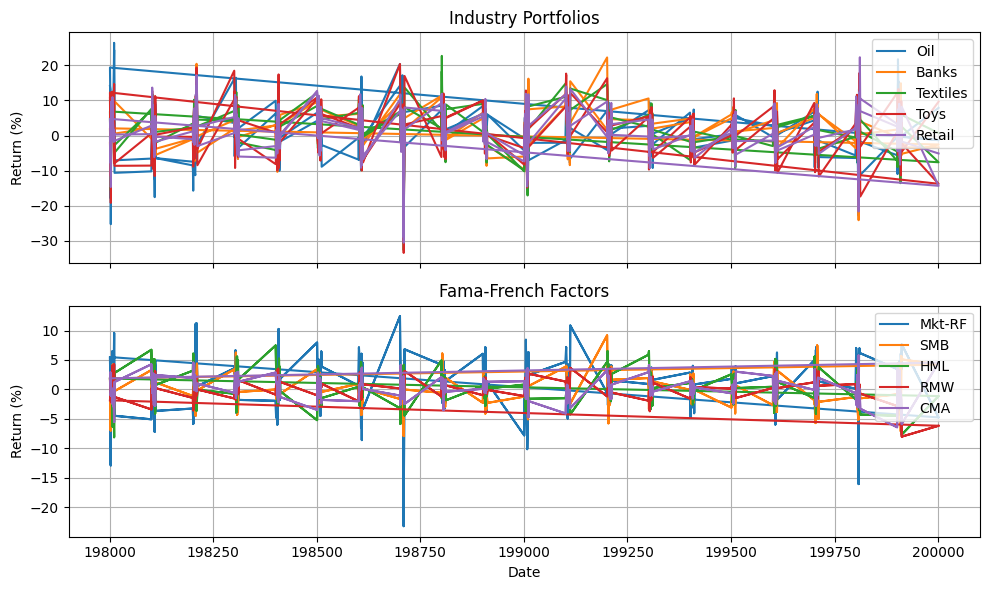

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
#Setting the start and end date
start=  198001
end=    200001
# Load the CSV
returns = pd.read_csv('49_Industry_Portfolios.csv', skiprows=11, engine='python', on_bad_lines='skip')
FF5=pd.read_csv('F-F_Research_Data_5_Factors_2x3.csv', skiprows=4, engine='python', on_bad_lines='skip')

# Rename the first column to 'Date'
returns = returns.rename(columns={returns.columns[0]: 'Date'})
FF5 = FF5.rename(columns={FF5.columns[0]: 'Date'})

#Cleaning up the column strings to remove white space
returns.columns = returns.columns.str.strip()
FF5.columns = FF5.columns.str.strip()

# Choosing which industries to use
keep_cols = ['Date', 'Oil', 'Banks', 'Txtls', 'Toys', 'Rtail']

# Only keep the chosen industry returns
returns = returns[keep_cols]

# Removing the unused rows
returns = returns.iloc[:2402].reset_index(drop=True)
FF5 = FF5.iloc[:756].reset_index(drop=True)


# Merge the data
data = pd.merge(returns, FF5, on='Date', how='inner')

# Change data type to numeric
data = data.apply(pd.to_numeric, errors='coerce')

#Using only the years we want
filtered_data = data[data["Date"].between(start, end)]

#
desc_stats = pd.DataFrame(
    {
        'mean': filtered_data.drop(columns=['Date',"RF"]).mean(),
        'std': filtered_data.drop(columns=['Date',"RF"]).std(),
        'min': filtered_data.drop(columns=['Date',"RF"]).min(),
        '25% Quartile': filtered_data.drop(columns=['Date',"RF"]).quantile(0.25),
        '50% (Median)': filtered_data.drop(columns=['Date',"RF"]).median(),
        '75% Quartile': filtered_data.drop(columns=['Date',"RF"]).quantile(0.75),
        'max': filtered_data.drop(columns=['Date',"RF"]).max(),
    }
)

print(desc_stats)

# Create 2 subplots sharing the same x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# 1. Plot 5 Industry Portfolios
ax1.plot(filtered_data["Date"], filtered_data["Oil"], label="Oil")
ax1.plot(filtered_data["Date"], filtered_data["Banks"], label="Banks")
ax1.plot(filtered_data["Date"], filtered_data["Txtls"], label="Textiles")
ax1.plot(filtered_data["Date"], filtered_data["Toys"], label="Toys")
ax1.plot(filtered_data["Date"], filtered_data["Rtail"], label="Retail")

ax1.set_title("Industry Portfolios")
ax1.set_ylabel("Return (%)")
ax1.legend(loc="upper right")
ax1.grid(True)

# 2. Plot Fama-French Factors
ax2.plot(filtered_data["Date"], filtered_data["Mkt-RF"], label="Mkt-RF")
ax2.plot(filtered_data["Date"], filtered_data["SMB"], label="SMB")
ax2.plot(filtered_data["Date"], filtered_data["HML"], label="HML")
ax2.plot(filtered_data["Date"], filtered_data["RMW"], label="RMW")
ax2.plot(filtered_data["Date"], filtered_data["CMA"], label="CMA")


ax2.set_title("Fama-French Factors")
ax2.set_xlabel("Date")
ax2.set_ylabel("Return (%)")
ax2.legend(loc="upper right")
ax2.grid(True)

# Adjust layout and display
plt.tight_layout()
plt.show()